In [1]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Setting the Style
sns.set_style("whitegrid")

In [3]:
# Import Dataset
from google.colab import files

uploaded = files.upload()

Saving NY-House-Dataset.csv to NY-House-Dataset.csv


In [4]:
df = pd.read_csv(list(uploaded.keys())[0])

In [5]:
df.head()

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.0,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.0,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.0,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.0,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856


In [6]:
# Checking rows and columns
df.shape

(4801, 17)

In [7]:
# Understanding Dataset
df.columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
df.info()
df.describe()

Number of rows: 4801
Number of columns: 17
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4801 entries, 0 to 4800
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4801 non-null   object 
 1   TYPE                         4801 non-null   object 
 2   PRICE                        4801 non-null   int64  
 3   BEDS                         4801 non-null   int64  
 4   BATH                         4801 non-null   float64
 5   PROPERTYSQFT                 4801 non-null   float64
 6   ADDRESS                      4801 non-null   object 
 7   STATE                        4801 non-null   object 
 8   MAIN_ADDRESS                 4801 non-null   object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  4801 non-null   object 
 10  LOCALITY                     4801 non-null   object 
 11  SUBLOCALITY                  4801 non-null   object 
 12  STREET_NAME                  4801

,PRICE,BEDS,BATH,PROPERTYSQFT,LATITUDE,LONGITUDE
count,4.801000e+03,4801.000000,4801.000000,4801.000000,4801.000000,4801.000000
mean,2.356940e+06,3.356801,2.373861,2184.207862,40.714227,-73.941601
std,3.135525e+07,2.602315,1.946962,2377.140894,0.087676,0.101082
min,2.494000e+03,1.000000,0.000000,230.000000,40.499546,-74.253033
25%,4.990000e+05,2.000000,1.000000,1200.000000,40.639375,-73.987143
50%,8.250000e+05,3.000000,2.000000,2184.207862,40.726749,-73.949189
75%,1.495000e+06,4.000000,3.000000,2184.207862,40.771923,-73.870638
max,2.147484e+09,50.000000,50.000000,65535.000000,40.912729,-73.702450


In [8]:
# Checking missing values

df.isnull().sum()

,0
BROKERTITLE,0
TYPE,0
PRICE,0
BEDS,0
BATH,0
PROPERTYSQFT,0
ADDRESS,0
STATE,0
MAIN_ADDRESS,0
ADMINISTRATIVE_AREA_LEVEL_2,0


In [9]:
# Checking for duplicates

df.duplicated().sum()

np.int64(214)

In [10]:
# Removing duplicate rows

df = df.drop_duplicates()

print("Number of rows after removing duplicates:", df.shape[0])
print("Number of duplicate rows:", df.duplicated().sum())

Number of rows after removing duplicates: 4587
Number of duplicate rows: 0


In [11]:
# Checking minimum and maximum values

print("PRICE range:")
print("Minimum:", df["PRICE"].min())
print("Maximum:", df["PRICE"].max())

print("\nBEDS range:")
print("Minimum:", df["BEDS"].min())
print("Maximum:", df["BEDS"].max())

print("\nBATH range:")
print("Minimum:", df["BATH"].min())
print("Maximum:", df["BATH"].max())

print("\nPROPERTYSQFT range:")
print("Minimum:", df["PROPERTYSQFT"].min())
print("Maximum:", df["PROPERTYSQFT"].max())

PRICE range:
Minimum: 2494
Maximum: 2147483647

BEDS range:
Minimum: 1
Maximum: 50

BATH range:
Minimum: 0.0
Maximum: 50.0

PROPERTYSQFT range:
Minimum: 230.0
Maximum: 65535.0


In [12]:
# 10 most expensive properties

df.nlargest(10, "PRICE")[["PRICE", "BEDS", "BATH", "PROPERTYSQFT", "TYPE", "LOCALITY"]]

,PRICE,BEDS,BATH,PROPERTYSQFT,TYPE,LOCALITY
304,2147483647,7,6.000000,10000.000000,House for sale,New York
1,195000000,7,10.000000,17545.000000,Condo for sale,New York
69,65000000,3,2.373861,15200.000000,Townhouse for sale,New York
1075,60000000,8,8.000000,2184.207862,Co-op for sale,New York County
141,56000000,11,10.000000,24000.000000,House for sale,New York
4,55000000,7,2.373861,14175.000000,Townhouse for sale,New York
99,55000000,8,8.000000,12000.000000,House for sale,New York
626,50000000,6,6.000000,6569.000000,Condo for sale,New York County
1453,48000000,5,2.373861,2184.207862,Co-op for sale,New York County
3388,45000000,5,2.373861,2184.207862,Co-op for sale,New York County


In [13]:
# 10 or more bedrooms

df[df["BEDS"] >= 10][["PRICE", "BEDS", "BATH", "PROPERTYSQFT", "TYPE", "LOCALITY"]]

,PRICE,BEDS,BATH,PROPERTYSQFT,TYPE,LOCALITY
27,2250000,12,2.373861,5670.000000,Multi-family home for sale,United States
29,1299888,10,6.000000,3156.000000,Multi-family home for sale,Richmond County
32,1300000,10,8.000000,5040.000000,Multi-family home for sale,Richmond County
36,1299888,11,4.000000,3156.000000,Multi-family home for sale,Richmond County
133,1150000,12,6.000000,5508.000000,Multi-family home for sale,New York
...,...,...,...,...,...,...
4501,10750000,10,10.000000,6532.000000,Townhouse for sale,New York
4523,1900000,14,6.000000,2184.207862,Multi-family home for sale,New York
4689,2499000,12,6.000000,2184.207862,Multi-family home for sale,United States
4786,1380000,12,3.000000,2681.000000,Multi-family home for sale,New York


In [14]:
# 10 or more bathrooms

df[df["BATH"] >= 10][["PRICE", "BEDS", "BATH", "PROPERTYSQFT", "TYPE", "LOCALITY"]]

,PRICE,BEDS,BATH,PROPERTYSQFT,TYPE,LOCALITY
1,195000000,7,10.0,17545.000000,Condo for sale,New York
7,16800000,8,16.0,33000.000000,House for sale,New York
141,56000000,11,10.0,24000.000000,House for sale,New York
222,29200000,12,10.0,11638.000000,Townhouse for sale,New York
270,3000000,10,10.0,2184.207862,Multi-family home for sale,New York
622,3000000,3,32.0,11760.000000,Multi-family home for sale,New York
631,29950000,10,13.0,8750.000000,Townhouse for sale,New York
750,7999000,20,10.0,2184.207862,Multi-family home for sale,New York
765,4380000,35,16.0,15000.000000,Multi-family home for sale,New York
936,2800000,16,16.0,10720.000000,Multi-family home for sale,New York


In [15]:
# Properties larger than 10,000 square feet

df[df["PROPERTYSQFT"] > 10000][
    ["PRICE", "BEDS", "BATH", "PROPERTYSQFT", "TYPE", "LOCALITY"]
]

,PRICE,BEDS,BATH,PROPERTYSQFT,TYPE,LOCALITY
1,195000000,7,10.000000,17545.0,Condo for sale,New York
4,55000000,7,2.373861,14175.0,Townhouse for sale,New York
7,16800000,8,16.000000,33000.0,House for sale,New York
69,65000000,3,2.373861,15200.0,Townhouse for sale,New York
99,55000000,8,8.000000,12000.0,House for sale,New York
141,56000000,11,10.000000,24000.0,House for sale,New York
181,39995000,4,2.373861,10582.0,Townhouse for sale,New York
222,29200000,12,10.000000,11638.0,Townhouse for sale,New York
601,28500000,7,9.000000,12300.0,Townhouse for sale,New York
622,3000000,3,32.000000,11760.0,Multi-family home for sale,New York


In [16]:
# Check the property with the maximum price

df[df["PRICE"] == df["PRICE"].max()]

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
304,Brokered by ANNE LOPA REAL ESTATE,House for sale,2147483647,7,6.0,10000.0,6659-6675 Amboy Rd,"New York, NY 10309","6659-6675 Amboy RdNew York, NY 10309",United States,New York,Richmond County,Staten Island,Amboy Road,"6659 Amboy Rd, Staten Island, NY 10309, USA",40.518484,-74.224418


In [17]:
# Check the property with the minimum price

df[df["PRICE"] == df["PRICE"].min()]

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
317,Brokered by Living NY - Main Office,For sale,2494,2,1.0,2184.207862,635 W 170th St Apt 4F,"New York, NY 10032","635 W 170th St Apt 4FNew York, NY 10032",New York,New York County,New York,Manhattan,635,"635 W 170th St #4f, New York, NY 10032, USA",40.843406,-73.940795


In [18]:
# Remove the invalid maximum price

df = df[df["PRICE"] != 2147483647]

print("Rows after removing invalid price:", df.shape[0])
print("New maximum price:", df["PRICE"].max())

Rows after removing invalid price: 4586
New maximum price: 195000000


In [19]:
# 20 properties with the lowest prices

df.nsmallest(20, "PRICE")[[
    "PRICE",
    "BEDS",
    "BATH",
    "PROPERTYSQFT",
    "TYPE",
    "LOCALITY",
    "ADDRESS"
]]

,PRICE,BEDS,BATH,PROPERTYSQFT,TYPE,LOCALITY,ADDRESS
317,2494,2,1.000000,2184.207862,For sale,New York County,635 W 170th St Apt 4F
310,3225,3,1.000000,2184.207862,For sale,New York County,635 W 170th St Apt 2C
360,5800,3,2.373861,2184.207862,Land for sale,Kings County,4515 Avenue N Lot 5
463,49500,3,2.373861,800.000000,Co-op for sale,Bronx County,150 City Island Ave Unit E3
979,60000,3,1.000000,445.000000,Condo for sale,New York County,2 E 55th St Unit 809W35
188,65000,3,1.000000,230.000000,For sale,New York County,1287266 45 Madison St Unit 1
3,69000,3,1.000000,445.000000,Condo for sale,New York,2 E 55th St Unit 908W33
252,69000,1,1.000000,850.000000,Co-op for sale,Bronx County,1185 Anderson Ave Apt 2E
132,69900,2,1.000000,700.000000,Co-op for sale,New York,61 Edgewater Park Unit B
4003,75000,3,2.373861,2184.207862,Land for sale,United States,199th St


In [20]:
# Removing extremely low and suspicious property prices

df = df[df["PRICE"] >= 10000]

print("Rows after removing suspicious low prices:", df.shape[0])
print("Minimum price:", df["PRICE"].min())

Rows after removing suspicious low prices: 4583
Minimum price: 49500


In [21]:
print("Number of properties with PROPERTYSQFT = 2184.207862:")
print((df["PROPERTYSQFT"] == 2184.207862).sum())

Number of properties with PROPERTYSQFT = 2184.207862:
1536


In [22]:
# maximum square footage

df[df["PROPERTYSQFT"] == df["PROPERTYSQFT"].max()][[
    "PRICE",
    "BEDS",
    "BATH",
    "PROPERTYSQFT",
    "TYPE",
    "LOCALITY",
    "ADDRESS"
]]

,PRICE,BEDS,BATH,PROPERTYSQFT,TYPE,LOCALITY,ADDRESS
4623,31500000,3,2.373861,65535.0,Multi-family home for sale,New York,467 Keap St


In [23]:
print((df["PROPERTYSQFT"] == 65535).sum())

1


In [24]:
# property square footage values

print("Number of properties with PROPERTYSQFT = 2184.207862:",
      (df['PROPERTYSQFT'] == 2184.207862).sum())

print("Number of properties with PROPERTYSQFT = 65535:",
      (df['PROPERTYSQFT'] == 65535).sum())

print("\nLargest 20 property sizes:")
print(
    df[['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'TYPE', 'LOCALITY', 'ADDRESS']]
    .sort_values('PROPERTYSQFT', ascending=False)
    .head(20)
)

print("\nProperty sqft summary:")
print(df['PROPERTYSQFT'].describe())

Number of properties with PROPERTYSQFT = 2184.207862: 1536
Number of properties with PROPERTYSQFT = 65535: 1

Largest 20 property sizes:
          PRICE  BEDS       BATH  PROPERTYSQFT                        TYPE  \
4623   31500000     3   2.373861       65535.0  Multi-family home for sale   
2146    5827000     3   2.373861       55300.0  Multi-family home for sale   
823     7200000     3   2.373861       48000.0  Multi-family home for sale   
7      16800000     8  16.000000       33000.0              House for sale   
3130    6950000     6   6.000000       32000.0  Multi-family home for sale   
2653   10700000    42  43.000000       27152.0  Multi-family home for sale   
141    56000000    11  10.000000       24000.0              House for sale   
2932   14000000     3   2.373861       23027.0              House for sale   
1143   11000000    50  50.000000       22035.0  Multi-family home for sale   
2054    2300000     3   2.373861       21000.0  Multi-family home for sale   
917  

In [25]:
# Analyze the repeated PROPERTYSQFT value

default_sqft = 2184.207862

print("Properties with repeated sqft value:")
print(df[df['PROPERTYSQFT'] == default_sqft]['TYPE'].value_counts())

print("\nRepeated sqft by locality:")
print(df[df['PROPERTYSQFT'] == default_sqft]['LOCALITY'].value_counts())

print("\nRepeated sqft by number of bedrooms:")
print(df[df['PROPERTYSQFT'] == default_sqft]['BEDS'].value_counts().sort_index())

Properties with repeated sqft value:
TYPE
Co-op for sale                717
House for sale                255
Multi-family home for sale    243
Condo for sale                109
Pending                        85
Townhouse for sale             61
Land for sale                  45
Contingent                      8
For sale                        6
Condop for sale                 4
Foreclosure                     1
Coming Soon                     1
Mobile house for sale           1
Name: count, dtype: int64

Repeated sqft by locality:
LOCALITY
New York           729
New York County    412
Queens County      266
Kings County        79
Bronx County        33
United States       10
Richmond County      3
Queens               3
The Bronx            1
Name: count, dtype: int64

Repeated sqft by number of bedrooms:
BEDS
1     328
2     309
3     463
4     161
5     100
6      89
7      26
8      22
9      11
10      5
11      6
12      8
13      3
14      2
15      1
16      1
20      1
Name: c

In [26]:
import numpy as np

df['PROPERTYSQFT'] = df['PROPERTYSQFT'].replace(2184.207862, np.nan)

print("Missing PROPERTYSQFT after replacement:",
      df['PROPERTYSQFT'].isna().sum())

Missing PROPERTYSQFT after replacement: 1536


In [27]:
df[df['PROPERTYSQFT'] == 65535][
    ['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT',
     'TYPE', 'LOCALITY', 'ADDRESS']
]

,PRICE,BEDS,BATH,PROPERTYSQFT,TYPE,LOCALITY,ADDRESS
4623,31500000,3,2.373861,65535.0,Multi-family home for sale,New York,467 Keap St


In [28]:
df['PROPERTYSQFT'] = df['PROPERTYSQFT'].replace([2184.207862, 65535], np.nan)

In [29]:
# Check high bedroom counts
df[df['BEDS'] >= 10][
    ['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'TYPE', 'LOCALITY', 'ADDRESS']
]

,PRICE,BEDS,BATH,PROPERTYSQFT,TYPE,LOCALITY,ADDRESS
27,2250000,12,2.373861,5670.0,Multi-family home for sale,United States,2361 81st St
29,1299888,10,6.000000,3156.0,Multi-family home for sale,Richmond County,310-312 Hillside Ave
32,1300000,10,8.000000,5040.0,Multi-family home for sale,Richmond County,366 Union Ave Unit 4
36,1299888,11,4.000000,3156.0,Multi-family home for sale,Richmond County,310-312 Hillside Ave
133,1150000,12,6.000000,5508.0,Multi-family home for sale,New York,32-40 48 St
...,...,...,...,...,...,...,...
4501,10750000,10,10.000000,6532.0,Townhouse for sale,New York,49 W 16th St Unit Townhouse
4523,1900000,14,6.000000,NaN,Multi-family home for sale,New York,1792 Saint Johns Pl
4689,2499000,12,6.000000,NaN,Multi-family home for sale,United States,755 Coney Island Ave
4786,1380000,12,3.000000,2681.0,Multi-family home for sale,New York,164-08 85th Ave


In [30]:
# Check high bathroom counts
df[df['BATH'] >= 10][
    ['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'TYPE', 'LOCALITY', 'ADDRESS']
]

,PRICE,BEDS,BATH,PROPERTYSQFT,TYPE,LOCALITY,ADDRESS
1,195000000,7,10.0,17545.0,Condo for sale,New York,Central Park Tower Penthouse-217 W 57th New Yo...
7,16800000,8,16.0,33000.0,House for sale,New York,177 Benedict Rd
141,56000000,11,10.0,24000.0,House for sale,New York,9 W 54th St
222,29200000,12,10.0,11638.0,Townhouse for sale,New York,123 E 35th St
270,3000000,10,10.0,NaN,Multi-family home for sale,New York,120 Pierrepont St
622,3000000,3,32.0,11760.0,Multi-family home for sale,New York,8001 New Utrecht Ave
631,29950000,10,13.0,8750.0,Townhouse for sale,New York,26 Washington Sq N
750,7999000,20,10.0,NaN,Multi-family home for sale,New York,414 Riverside Dr
765,4380000,35,16.0,15000.0,Multi-family home for sale,New York,8699 Bay Pkwy Unit 16
936,2800000,16,16.0,10720.0,Multi-family home for sale,New York,1570 66th St


In [31]:
print("BEDS <= 0:", (df['BEDS'] <= 0).sum())
print("BATH < 0:", (df['BATH'] < 0).sum())

print("Missing BEDS:", df['BEDS'].isna().sum())
print("Missing BATH:", df['BATH'].isna().sum())

BEDS <= 0: 0
BATH < 0: 0
Missing BEDS: 0
Missing BATH: 0


In [32]:
df['PRICE'].describe()
df.nlargest(20, 'PRICE')[
    ['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'TYPE', 'LOCALITY', 'ADDRESS']
]

,PRICE,BEDS,BATH,PROPERTYSQFT,TYPE,LOCALITY,ADDRESS
1,195000000,7,10.000000,17545.0,Condo for sale,New York,Central Park Tower Penthouse-217 W 57th New Yo...
69,65000000,3,2.373861,15200.0,Townhouse for sale,New York,4 E 79th St
1075,60000000,8,8.000000,NaN,Co-op for sale,New York County,960 5th Ave Unit 12
141,56000000,11,10.000000,24000.0,House for sale,New York,9 W 54th St
4,55000000,7,2.373861,14175.0,Townhouse for sale,New York,5 E 64th St
99,55000000,8,8.000000,12000.0,House for sale,New York,25 Riverside Dr
626,50000000,6,6.000000,6569.0,Condo for sale,New York County,100 Vandam St Apt 20A
1453,48000000,5,2.373861,NaN,Co-op for sale,New York County,740 Park Ave # 4 & 5B
3388,45000000,5,2.373861,NaN,Co-op for sale,New York County,4 E 66th St Fl 7
3571,44500000,5,6.000000,NaN,Co-op for sale,New York County,2 E 67th St Fl 9


In [33]:
df['PROPERTYSQFT'].describe()
print("Missing sqft:", df['PROPERTYSQFT'].isna().sum())
print("Minimum sqft:", df['PROPERTYSQFT'].min())
print("Maximum sqft:", df['PROPERTYSQFT'].max())

Missing sqft: 1537
Minimum sqft: 230.0
Maximum sqft: 55300.0


In [34]:
# Check duplicate rows
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [35]:
# Check likely duplicate properties
duplicate_properties = df.duplicated(
    subset=['ADDRESS', 'PRICE', 'BEDS', 'BATH']
).sum()

print("Potential duplicate properties:", duplicate_properties)

Potential duplicate properties: 2


In [36]:
for col in ['TYPE', 'STATE', 'LOCALITY', 'SUBLOCALITY']:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).head(20))


TYPE:
TYPE
Co-op for sale                1388
House for sale                 965
Condo for sale                 842
Multi-family home for sale     699
Townhouse for sale             288
Pending                        229
Contingent                      87
Land for sale                   46
For sale                        18
Foreclosure                     14
Condop for sale                  4
Coming Soon                      2
Mobile house for sale            1
Name: count, dtype: int64

STATE:
STATE
Brooklyn, NY 11235           99
Brooklyn, NY 11209           91
Forest Hills, NY 11375       88
Brooklyn, NY 11234           86
Staten Island, NY 10314      80
Bronx, NY 10463              72
Staten Island, NY 10306      68
Staten Island, NY 10312      67
Staten Island, NY 10301      57
Brooklyn, NY 11201           57
Rego Park, NY 11374          56
Jackson Heights, NY 11372    55
Staten Island, NY 10304      55
Bronx, NY 10471              52
New York, NY 10023           51
Brooklyn, NY 

In [37]:
print(df.isnull().sum().sort_values(ascending=False))

PROPERTYSQFT                   1537
BROKERTITLE                       0
TYPE                              0
BEDS                              0
PRICE                             0
BATH                              0
ADDRESS                           0
STATE                             0
MAIN_ADDRESS                      0
ADMINISTRATIVE_AREA_LEVEL_2       0
LOCALITY                          0
SUBLOCALITY                       0
STREET_NAME                       0
LONG_NAME                         0
FORMATTED_ADDRESS                 0
LATITUDE                          0
LONGITUDE                         0
dtype: int64


In [38]:
print(df.dtypes)

BROKERTITLE                     object
TYPE                            object
PRICE                            int64
BEDS                             int64
BATH                           float64
PROPERTYSQFT                   float64
ADDRESS                         object
STATE                           object
MAIN_ADDRESS                    object
ADMINISTRATIVE_AREA_LEVEL_2     object
LOCALITY                        object
SUBLOCALITY                     object
STREET_NAME                     object
LONG_NAME                       object
FORMATTED_ADDRESS               object
LATITUDE                       float64
LONGITUDE                      float64
dtype: object


In [39]:
print("Invalid latitude:", ((df['LATITUDE'] < -90) | (df['LATITUDE'] > 90)).sum())
print("Invalid longitude:", ((df['LONGITUDE'] < -180) | (df['LONGITUDE'] > 180)).sum())

Invalid latitude: 0
Invalid longitude: 0


In [40]:
clean_df = df.copy()

print("Clean dataset shape:", clean_df.shape)

Clean dataset shape: (4583, 17)


In [41]:
clean_df.to_csv("cleaned_real_estate.csv", index=False)
print("Saved successfully.")

Saved successfully.


In [42]:
clean_df['PRICE'].describe()

,PRICE
count,4.583000e+03
mean,1.914671e+06
std,4.980430e+06
min,4.950000e+04
25%,4.990000e+05
50%,8.250000e+05
75%,1.498500e+06
max,1.950000e+08


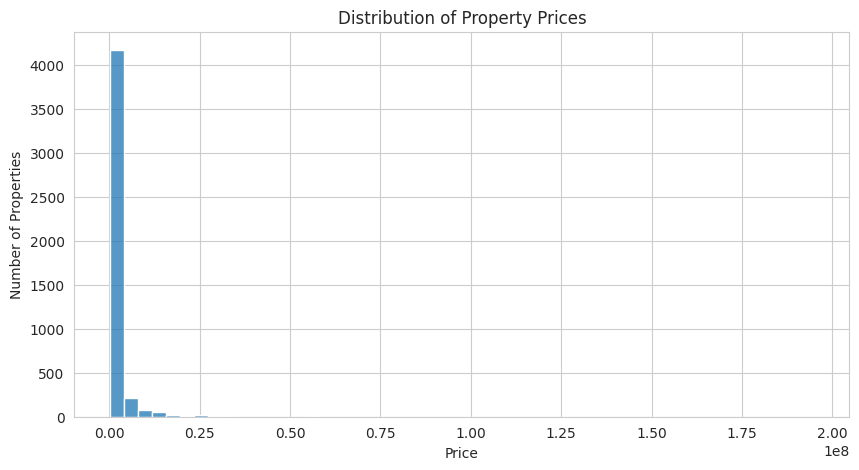

In [43]:
plt.figure(figsize=(10, 5))
sns.histplot(clean_df['PRICE'], bins=50)
plt.title('Distribution of Property Prices')
plt.xlabel('Price')
plt.ylabel('Number of Properties')
plt.show()

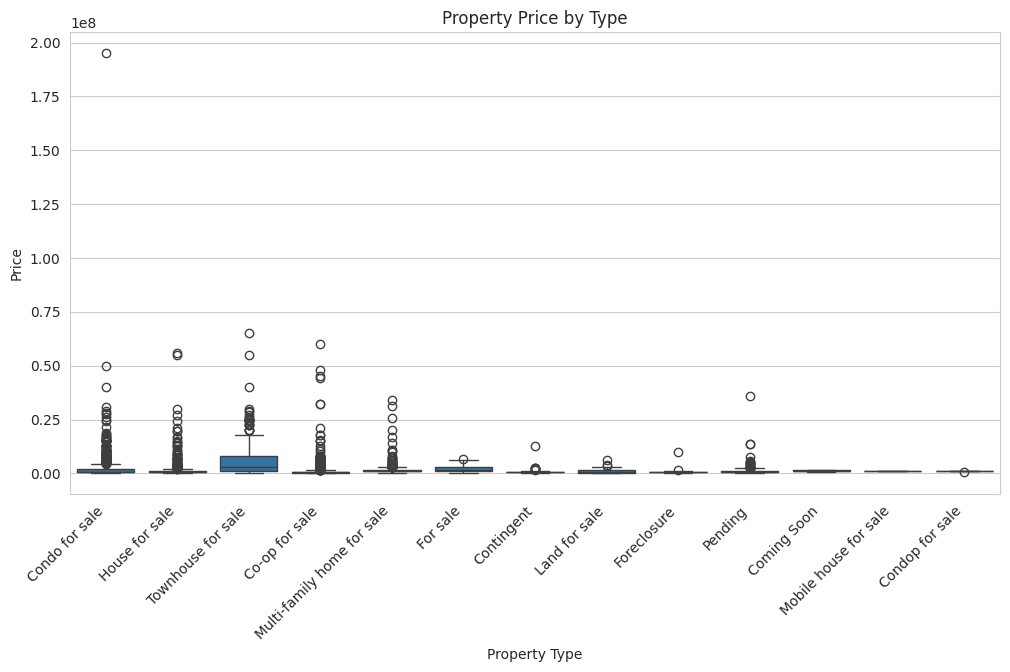

In [44]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=clean_df, x='TYPE', y='PRICE')
plt.xticks(rotation=45, ha='right')
plt.title('Property Price by Type')
plt.ylabel('Price')
plt.xlabel('Property Type')
plt.show()

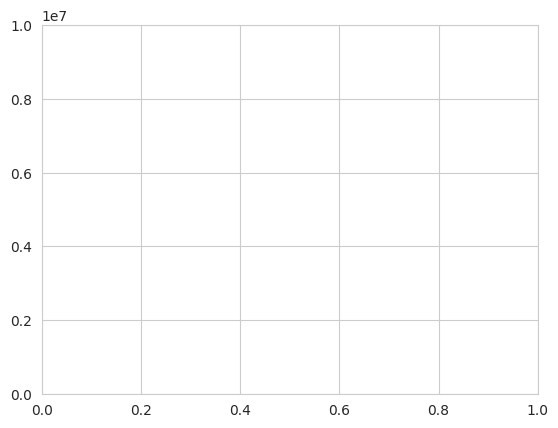

In [45]:
plt.ylim(0, 10000000)
plt.show()

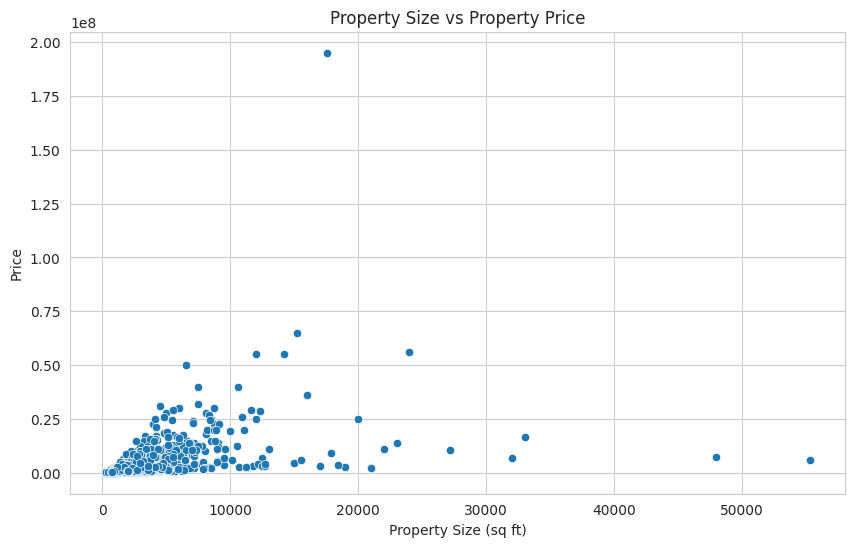

In [46]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=clean_df, x='PROPERTYSQFT', y='PRICE')

plt.xlabel('Property Size (sq ft)')
plt.ylabel('Price')
plt.title('Property Size vs Property Price')

plt.show()

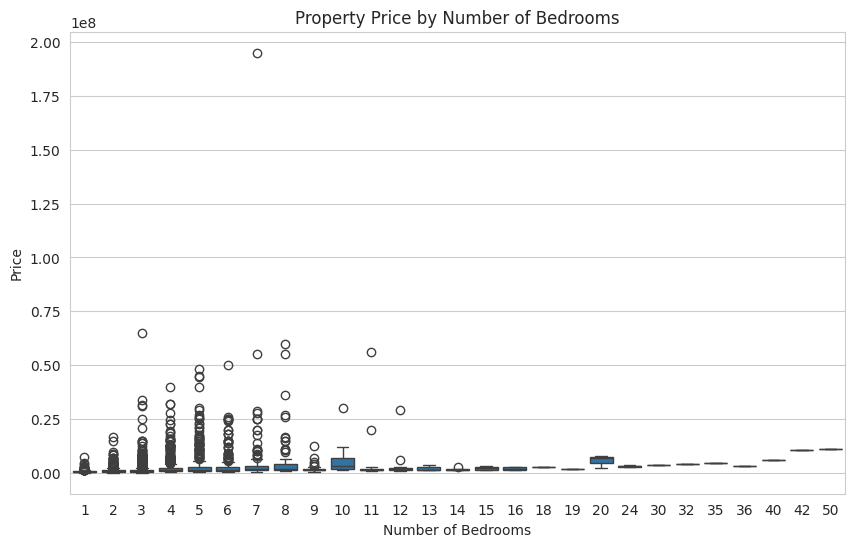

In [47]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=clean_df, x='BEDS', y='PRICE')

plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')
plt.title('Property Price by Number of Bedrooms')

plt.show()

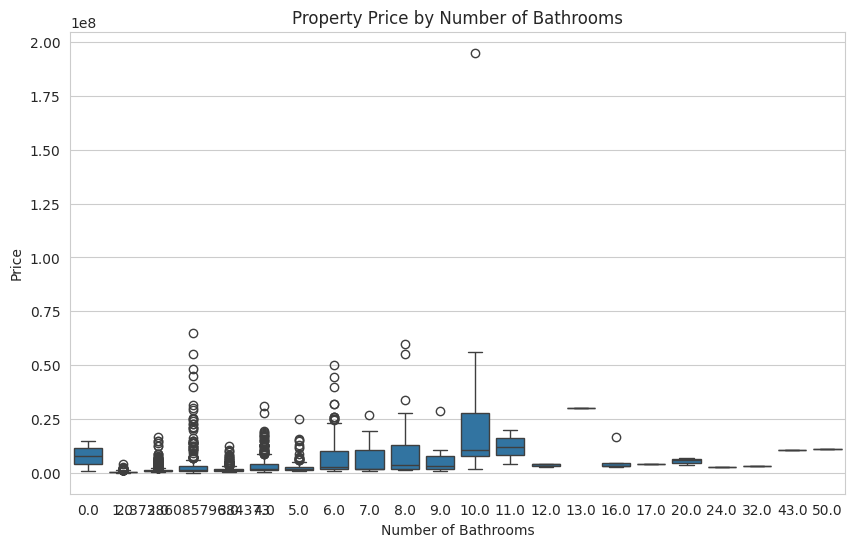

In [48]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=clean_df, x='BATH', y='PRICE')

plt.xlabel('Number of Bathrooms')
plt.ylabel('Price')
plt.title('Property Price by Number of Bathrooms')

plt.show()

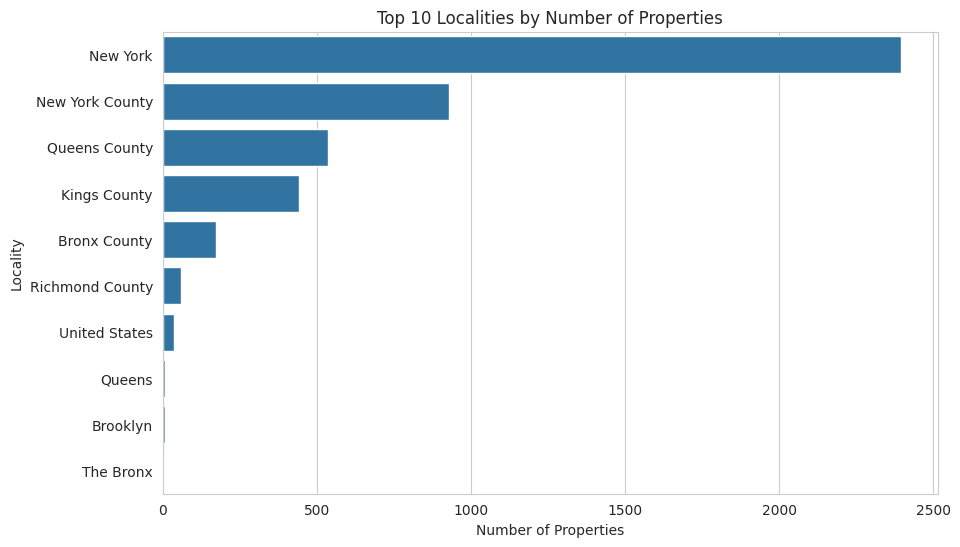

In [49]:
top_localities = clean_df['LOCALITY'].value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(x=top_localities.values, y=top_localities.index)

plt.xlabel('Number of Properties')
plt.ylabel('Locality')
plt.title('Top 10 Localities by Number of Properties')

plt.show()

In [50]:
clean_df[['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT']].describe()

,PRICE,BEDS,BATH,PROPERTYSQFT
count,4.583000e+03,4583.000000,4583.000000,3046.000000
mean,1.914671e+06,3.365481,2.377547,2151.062377
std,4.980430e+06,2.629319,1.968424,2551.735868
min,4.950000e+04,1.000000,0.000000,230.000000
25%,4.990000e+05,2.000000,1.000000,953.500000
50%,8.250000e+05,3.000000,2.000000,1495.500000
75%,1.498500e+06,4.000000,3.000000,2455.000000
max,1.950000e+08,50.000000,50.000000,55300.000000


In [51]:
clean_df.duplicated().sum()

np.int64(0)

In [52]:
clean_df.isnull().sum()

,0
BROKERTITLE,0
TYPE,0
PRICE,0
BEDS,0
BATH,0
PROPERTYSQFT,1537
ADDRESS,0
STATE,0
MAIN_ADDRESS,0
ADMINISTRATIVE_AREA_LEVEL_2,0


In [53]:
clean_df['PROPERTYSQFT'] = clean_df['PROPERTYSQFT'].fillna(
    clean_df['PROPERTYSQFT'].median()
)

print("Missing values after handling:")
print(clean_df['PROPERTYSQFT'].isna().sum())

Missing values after handling:
0


In [54]:
clean_df.isnull().sum().sum()

np.int64(0)

In [55]:
print("Median Price:", clean_df['PRICE'].median())
print("Average Price:", clean_df['PRICE'].mean())
print("Average Bedrooms:", clean_df['BEDS'].mean())
print("Average Bathrooms:", clean_df['BATH'].mean())
print("Average Property Size:", clean_df['PROPERTYSQFT'].mean())

Median Price: 825000.0
Average Price: 1914671.468688632
Average Bedrooms: 3.3654811259000654
Average Bathrooms: 2.3775470360543185
Average Property Size: 1931.2065241108444
